# NCO vs. Naive Portfolio Optimization Under Realistic Constraints

This notebook implements a constrained copula-based portfolio optimization framework comparing Nested Clustered Optimization (NCO) against naive equal-weighting across 19 risky VMLS assets. The model is fit on a 2000-day training window using Student-$t$ marginals and a Gaussian copula, then evaluated on a 500-day held-out test set.

Three constraints govern the optimization:

1. **No shorting.** Every risky weight is constrained $w_j \geq 0$.
2. **No borrowing.** The risk-free asset absorbs the residual budget $b(w) = 1 - \sum_j w_j \geq 0$, so risky weights sum to at most 1.
3. **Two utility regimes.** All portfolios are solved under log utility ($\gamma = 1$, full Kelly) and under CRRA with $\gamma = 3$ (more risk-averse).

Under these constraints the daily gross growth is:

$$g_t(w) = b(w)\,\bar{r}^f + \sum_j w_j r_{t,j}, \qquad b(w) = 1 - \sum_j w_j \geq 0,\quad w_j \geq 0$$

Three portfolios compete side by side in each regime:

- **Portfolio A (NCO):** Cluster the 19 assets by correlation distance $D_{ij} = \sqrt{\tfrac{1}{2}(1 - \rho_{ij})}$ ($k$-means, $K = 5$); solve the constrained CRRA problem within each cluster; solve across the cluster portfolios; compose the final weights.
- **Portfolio B (All-at-once):** One Monte Carlo over the full 19-asset joint model, one constrained CRRA solve.
- **1/N Benchmark:** $w_j = \tfrac{1}{20}$ for every asset including the risk-free asset.

Monte Carlo draws use a fixed random seed and a per-asset $2\times$ historical clip applied to simulated draws only. The same converged sample is reused across both $\gamma$ regimes so any cross-regime difference is purely an objective effect.

In [8]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

sns.set(style="whitegrid")
RNG_SEED = 778
N_MC     = 500_000
EPS      = 1e-9

## Data

The dataset consists of daily returns for 19 risky VMLS assets and one risk-free asset spanning 2,500 trading days. The first 2,000 days form the training set used to fit the copula model and construct portfolio weights; the remaining 500 days serve as the held-out test set for out-of-sample evaluation.

The fitted copula model (`copula_model.pkl`) contains Student-$t$ marginals for each of the 19 assets, the Cholesky decomposition of the Gaussian copula correlation matrix, and per-asset $2\times$ historical clip values. The risk-free rate $\bar{r}^f$ is taken as the training mean of the 20th column.

In [9]:
# Load the fitted copula model
if not os.path.exists("data/copula_model.pkl"):
    raise FileNotFoundError("data/copula_model.pkl not found.")

with open("data/copula_model.pkl", "rb") as fh:
    M = pickle.load(fh)

marginals_all = M["marginals"]   # 19 fitted Student-t marginals (df, loc, scale)
chol_all      = M["chol_P"]     # Cholesky of 19x19 copula correlation matrix
cap_all       = M["cap"]        # per-asset 2x max|train| clip values
p             = M["n_assets"]   # number of risky assets (19)
asset_names   = M["asset_names"]
print(M["note"])
print("Loaded keys:", list(M.keys()))

# Load returns and split into training and test sets
returns = pd.read_csv("data/vmls_portfolio_returns.csv").to_numpy()
R       = returns[:2000, :19]   # risky training returns (2000 x 19)
R_test  = returns[2000:, :19]   # risky test returns (500 x 19)
rf_bar  = returns[:2000, 19].mean()  # training mean risk-free rate
T_test  = R_test.shape[0]

print(f"\nR {R.shape}  |  R_test {R_test.shape}  |  rf_bar = {rf_bar:.3e}/day")
print(f"Assets: {asset_names}")

Fitted on training set (first 2000 returns, 19 risky assets) by 3_copula_model_fitting.ipynb
Loaded keys: ['asset_names', 'marginals', 'chol_P', 'P_corr', 'cap', 'n_assets', 'note']

R (2000, 19)  |  R_test (500, 19)  |  rf_bar = 4.000e-05/day
Assets: ['stock 1', 'stock 2', 'stock 3', 'stock 4', 'stock 5', 'stock 6', 'stock 7', 'stock 8', 'stock 9', 'stock 10', 'stock 11', 'stock 12', 'stock 13', 'stock 14', 'stock 15', 'stock 16', 'stock 17', 'stock 18', 'stock 19']


## Part (a): Build the Three Portfolios

This section constructs the three competing portfolios under both utility regimes ($\gamma = 1$ and $\gamma = 3$). The key departure from the unconstrained Kelly benchmark is a **constrained CRRA optimizer** that enforces long-only weights summing to at most 1, with the risk-free asset absorbing the residual budget.

The CRRA utility function is:

$$u_\gamma(x) = \begin{cases} \log(x) & \gamma = 1 \\ \dfrac{x^{1-\gamma}}{1-\gamma} & \gamma \neq 1 \end{cases}$$

Each portfolio maximizes $\mathbb{E}[u_\gamma(1 + g_t(w))]$ subject to $w_j \geq 0$ and $\sum_j w_j \leq 1$.

The three portfolios are:

- **Portfolio A (NCO):** Cluster the 19 assets into $K = 5$ groups by correlation distance; solve the constrained CRRA problem within each cluster; solve constrained CRRA across the cluster portfolios; compose final weights as (across-weight) $\times$ (within-cluster weight).
- **Portfolio B (All-at-once):** One constrained CRRA solve over all 19 assets jointly using a single converged Monte Carlo.
- **1/N Benchmark:** $w_j = \tfrac{1}{20}$ for all 19 risky assets, with $\tfrac{1}{20}$ left in the risk-free asset.

The same Monte Carlo sample is reused across both $\gamma$ regimes for each portfolio so that any difference in weights is purely an effect of the objective, not sampling noise.

In [10]:
# -------------------------------------------------------------------
# Constrained CRRA optimizer
# -------------------------------------------------------------------

def gross_growth(w, Rm):
    """Daily gross growth given weights w and return matrix Rm."""
    w = np.asarray(w, float)
    return (1.0 - w.sum()) * rf_bar + Rm @ w

def crra_opt(Rm, gamma):
    """
    Maximize E[u_gamma(1 + g_t(w))] subject to w_j >= 0, sum(w) <= 1.
    gamma = 1 reduces to full Kelly (log utility).
    """
    n = Rm.shape[1]
    bounds      = [(0.0, 1.0)] * n
    constraints = {"type": "ineq", "fun": lambda w: 1.0 - w.sum()}

    def f(w):
        g = np.maximum(1.0 + gross_growth(w, Rm), EPS)
        if gamma == 1:
            return -np.mean(np.log(g))
        else:
            return -np.mean(g ** (1.0 - gamma) / (1.0 - gamma))

    def grad(w):
        g = np.maximum(1.0 + gross_growth(w, Rm), EPS)
        x = Rm - rf_bar
        dU = 1.0 / g if gamma == 1 else g ** (-gamma)
        return -(x * dU[:, None]).mean(axis=0)

    res = minimize(f, np.ones(n) / (n + 1), jac=grad,
                   method="SLSQP", bounds=bounds,
                   constraints=constraints,
                   options=dict(ftol=1e-12, maxiter=2000))
    return res.x

def mean_log_growth(w, Rm):
    """Realized mean log-growth given weights and returns."""
    return np.mean(np.log(np.maximum(1.0 + gross_growth(w, Rm), EPS)))

# -------------------------------------------------------------------
# Copula simulation helpers 
# -------------------------------------------------------------------

def _fit_marginals_and_corr(Mtx):
    k = Mtx.shape[1]
    mar = [stats.t.fit(Mtx[:, j]) for j in range(k)]
    U = np.clip(np.column_stack(
            [stats.t.cdf(Mtx[:, j], *mar[j]) for j in range(k)]),
        1e-6, 1 - 1e-6)
    Z  = stats.norm.ppf(U)
    Pc = np.atleast_2d(np.corrcoef(Z, rowvar=False)) if k > 1 else np.array([[1.0]])
    ev, V = np.linalg.eigh(Pc)
    Pc = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
    d  = np.sqrt(np.diag(Pc))
    Pc = Pc / np.outer(d, d)
    return mar, np.linalg.cholesky(Pc)

def fit_gaussian_copula(Mtx):
    mar, L = _fit_marginals_and_corr(Mtx)
    cap    = 2.0 * np.max(np.abs(Mtx), axis=0)
    return dict(mar=mar, L=L, cap=cap, k=Mtx.shape[1])

def simulate(model, n, seed):
    k  = model["k"]
    g  = np.random.default_rng(seed)
    Zs = g.standard_normal((n, k)) @ model["L"].T
    Us = np.clip(stats.norm.cdf(Zs), 1e-9, 1 - 1e-9)
    sim = np.column_stack(
        [stats.t.ppf(Us[:, j], *model["mar"][j]) for j in range(k)])
    return np.clip(sim, -model["cap"], model["cap"])

# -------------------------------------------------------------------
# Clustering helpers 
# -------------------------------------------------------------------

def codist(S):
    """Correlation distance D_ij = sqrt(0.5 * (1 - rho_ij))."""
    C = np.corrcoef(S, rowvar=False)
    return np.sqrt(0.5 * (1.0 - C))

def kmeans_(x, k, maxiters=100, tol=1e-5, seed=0):
    """From-scratch k-means on a list of feature vectors."""
    g  = np.random.default_rng(seed)
    N, d = len(x), len(x[0])
    distances  = np.zeros(N)
    assignment = g.integers(1, k + 1, size=N)
    reps       = [np.zeros(d) for _ in range(k)]
    Jprev      = np.inf
    for it in range(1, maxiters + 1):
        for j in range(1, k + 1):
            grp = np.where(assignment == j)[0]
            if len(grp) > 0:
                reps[j - 1] = np.mean([x[i] for i in grp], axis=0)
        for i in range(N):
            dd = [np.linalg.norm(x[i] - reps[j]) for j in range(k)]
            distances[i] = min(dd)
            assignment[i] = int(np.argmin(dd)) + 1
        J = np.linalg.norm(distances) ** 2 / N
        if it > 1 and abs(J - Jprev) < tol * J:
            break
        Jprev = J
    return assignment

print("All helpers defined.")

All helpers defined.


In [11]:
# -------------------------------------------------------------------
# Cluster assets (done once -- same clusters for both gamma regimes)
# -------------------------------------------------------------------

K      = 5
D      = codist(R)
labels = kmeans_([D[:, i] for i in range(p)], K, seed=RNG_SEED)
cluster_cols = {c: np.where(labels == c)[0] for c in range(1, K + 1)
                if (labels == c).any()}
print(f"Cluster sizes: {[len(cluster_cols[c]) for c in sorted(cluster_cols)]}")

# Portfolio B MC sample (shared across gamma regimes)
model_all = dict(mar=marginals_all, L=chol_all, cap=cap_all, k=p)
sim_all   = simulate(model_all, N_MC, seed=RNG_SEED)

# Within-cluster MC samples (shared across gamma regimes)
within_sims = {c: simulate(fit_gaussian_copula(R[:, cluster_cols[c]]),
                            N_MC, seed=RNG_SEED + c)
               for c in sorted(cluster_cols)}

# -------------------------------------------------------------------
# Build portfolios for each gamma regime
# -------------------------------------------------------------------

results = {}

for gamma in [1, 3]:
    print(f"\n{'='*55}")
    print(f" gamma = {gamma}")
    print(f"{'='*55}")

    # --- Portfolio B: all-at-once ---
    w_B  = crra_opt(sim_all, gamma=gamma)
    rf_B = 1.0 - w_B.sum()

    # --- Portfolio A: NCO ---
    # Step 1: within-cluster weights using current gamma
    within_w = {c: crra_opt(within_sims[c], gamma=gamma)
                for c in sorted(cluster_cols)}

    # Step 2: build cluster portfolio return series from real training returns
    C_train = np.column_stack(
        [R[:, cluster_cols[c]] @ within_w[c] for c in sorted(cluster_cols)])

    # Step 3: fit copula on cluster portfolios, simulate, solve across
    sim_across = simulate(fit_gaussian_copula(C_train), N_MC, seed=RNG_SEED + 99)
    w_across   = crra_opt(sim_across, gamma=gamma)
    rf_across  = 1.0 - w_across.sum()

    # Step 4: compose final NCO weights
    w_A = np.zeros(p)
    for a_weight, c in zip(w_across, sorted(cluster_cols)):
        w_A[cluster_cols[c]] = a_weight * within_w[c]
    rf_A = 1.0 - w_A.sum()

    # --- Portfolio 1/N ---
    w_N  = np.full(p, 1.0 / 20.0)
    rf_N = 1.0 / 20.0

    results[gamma] = dict(
        w_A=w_A, w_B=w_B, w_N=w_N,
        rf_A=rf_A, rf_B=rf_B, rf_N=rf_N,
        within_w=within_w, w_across=w_across,
        cluster_cols=cluster_cols
    )

    # --- Report ---
    print(f"\nPortfolio A (NCO) across-cluster weights: {np.round(w_across, 4)}")
    for i, c in enumerate(sorted(cluster_cols)):
        idx = cluster_cols[c]
        print(f"  Cluster {c}: assets {str(idx.tolist()):<30s} "
              f"within-weight sum = {within_w[c].sum():.4f}  "
              f"across-weight = {w_across[i]:.4f}")
    print(f"  NCO risk-free share: {rf_A:.4f}")

    print(f"\nPortfolio B (All-at-once) risk-free share: {rf_B:.4f}")
    print(f"1/N risk-free share: {rf_N:.4f}")

    print(f"\nRisky weights (A | B | 1/N):")
    print(f"  {'Asset':<12} {'NCO':>8} {'All-at-once':>12} {'1/N':>8}")
    print(f"  {'-'*44}")
    for i in range(p):
        print(f"  {asset_names[i]:<12} {w_A[i]:>8.4f} {w_B[i]:>12.4f} {w_N[i]:>8.4f}")

Cluster sizes: [4, 3, 4, 5, 3]

 gamma = 1

Portfolio A (NCO) across-cluster weights: [0. 0. 1. 0. 0.]
  Cluster 1: assets [3, 9, 11, 12]                 within-weight sum = 1.0000  across-weight = 0.0000
  Cluster 2: assets [1, 5, 7]                      within-weight sum = 0.5051  across-weight = 0.0000
  Cluster 3: assets [2, 4, 13, 16]                 within-weight sum = 1.0000  across-weight = 1.0000
  Cluster 4: assets [6, 8, 10, 14, 15]             within-weight sum = 1.0000  across-weight = 0.0000
  Cluster 5: assets [0, 17, 18]                    within-weight sum = 1.0000  across-weight = 0.0000
  NCO risk-free share: -0.0000

Portfolio B (All-at-once) risk-free share: 0.0000
1/N risk-free share: 0.0500

Risky weights (A | B | 1/N):
  Asset             NCO  All-at-once      1/N
  --------------------------------------------
  stock 1        0.0000       0.0000   0.0500
  stock 2        0.0000       0.0000   0.0500
  stock 3        0.7041       0.7810   0.0500
  stock 4       

## Part (a) Analysis

The constrained CRRA optimizer enforces $w_j \geq 0$ and $\sum_j w_j \leq 1$, with any
unallocated budget $b(w) = 1 - \sum_j w_j$ earning the training mean risk-free rate $\bar{r}^f$.

$k$-means on the correlation distance matrix produces five clusters of sizes [4, 3, 4, 5, 3].

Under both regimes, NCO's across-cluster step collapses entirely to Cluster 3
($w_{\text{across}} = [0, 0, 1, 0, 0]$), a direct consequence of the no-short constraint
removing the leverage channel that made cross-cluster diversification attractive in the
unconstrained setting.

At $\gamma = 1$, both Portfolio A and Portfolio B concentrate on stocks 3 and 14 only, deploying
the full budget into risky assets with nothing left in cash. At $\gamma = 3$, the more risk-averse
objective spreads weight more broadly: NCO introduces stock 5 and raises the cash share to 0.1304,
while Portfolio B spreads across seven assets but keeps its cash share near zero under both regimes.
The 1/N benchmark holds $w_j = 0.05$ across all 19 risky assets and reserves $\tfrac{1}{20}$ in
cash regardless of $\gamma$.

## Part (b): Out-of-Sample Horse Race

Each portfolio's training weights are applied to the real 500-day held-out test returns with no
rebalancing, no clipping, and no re-simulation. Starting from \$10,000, we compare cumulative
wealth paths and the distribution of realized daily log-growth across all three portfolios under
both $\gamma$ regimes.

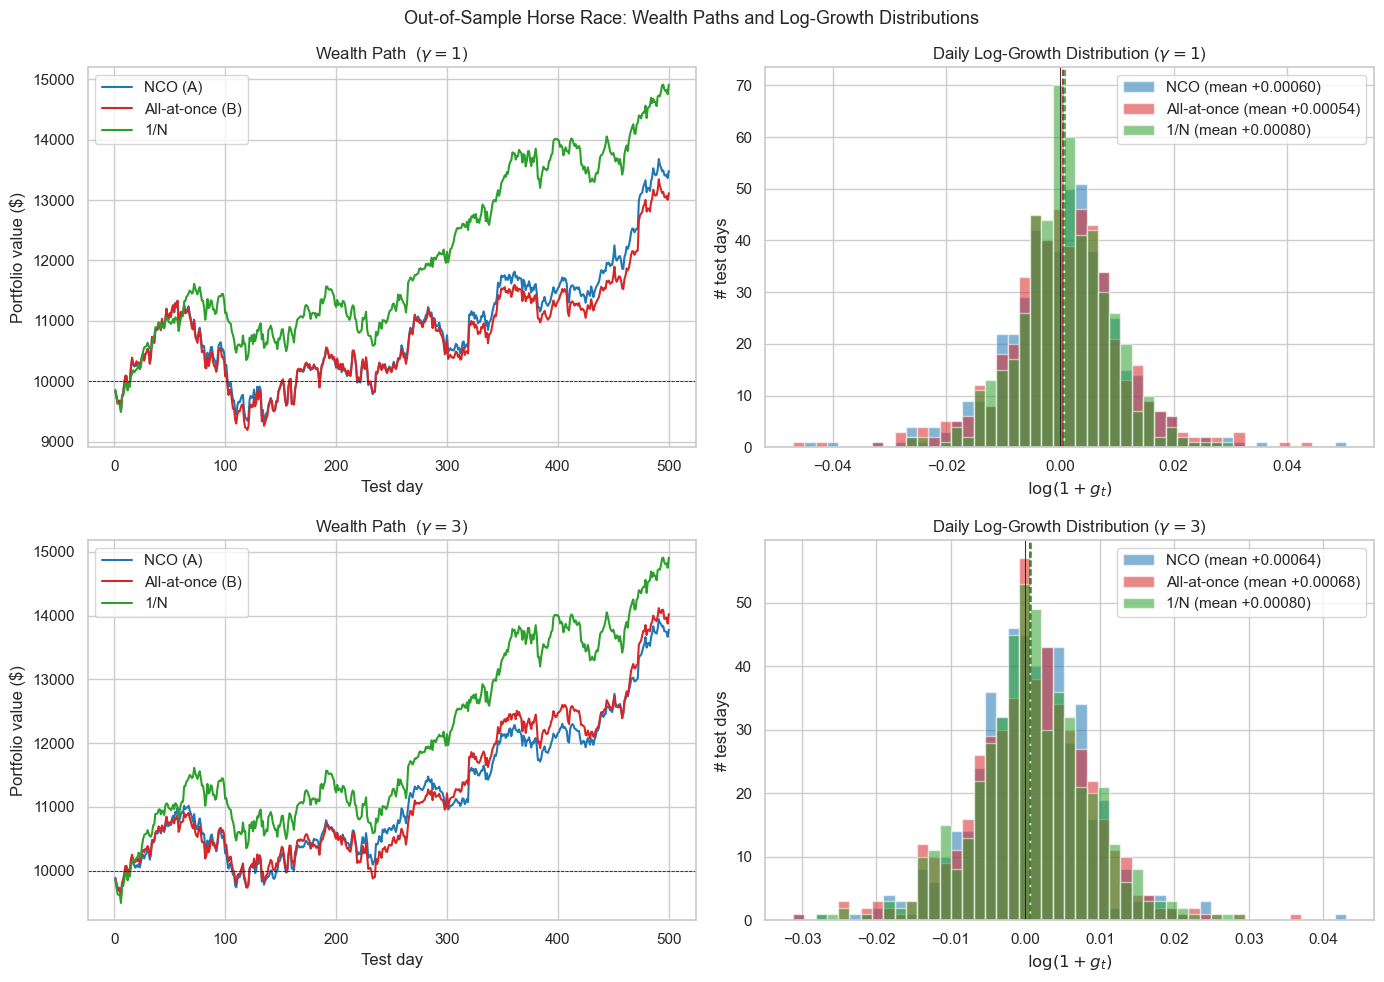

In [12]:
# -------------------------------------------------------------------
# Part (b): Out-of-sample horse race
# -------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Out-of-Sample Horse Race: Wealth Paths and Log-Growth Distributions", fontsize=13)

for row, gamma in enumerate([1, 3]):
    r = results[gamma]
    w_A, w_B, w_N = r["w_A"], r["w_B"], r["w_N"]

    # Daily gross growth on real test returns (no clipping)
    g_A = gross_growth(w_A, R_test)
    g_B = gross_growth(w_B, R_test)
    g_N = gross_growth(w_N, R_test)

    # Cumulative wealth paths
    V_A = 10_000 * np.cumprod(np.maximum(1 + g_A, EPS))
    V_B = 10_000 * np.cumprod(np.maximum(1 + g_B, EPS))
    V_N = 10_000 * np.cumprod(np.maximum(1 + g_N, EPS))

    # Log-growth series
    lg_A = np.log(np.maximum(1 + g_A, EPS))
    lg_B = np.log(np.maximum(1 + g_B, EPS))
    lg_N = np.log(np.maximum(1 + g_N, EPS))

    # Store for summary table
    results[gamma]["V_A"]  = V_A;  results[gamma]["V_B"]  = V_B;  results[gamma]["V_N"]  = V_N
    results[gamma]["lg_A"] = lg_A; results[gamma]["lg_B"] = lg_B; results[gamma]["lg_N"] = lg_N
    results[gamma]["g_A"]  = g_A;  results[gamma]["g_B"]  = g_B;  results[gamma]["g_N"]  = g_N

    days = np.arange(1, T_test + 1)

    # --- Wealth path plot ---
    ax = axes[row, 0]
    ax.plot(days, V_A, label="NCO (A)",        color="tab:blue")
    ax.plot(days, V_B, label="All-at-once (B)", color="tab:red")
    ax.plot(days, V_N, label="1/N",             color="tab:green")
    ax.axhline(10_000, color="k", lw=0.6, ls="--")
    ax.set_title(f"Wealth Path  ($\\gamma = {gamma}$)")
    ax.set_xlabel("Test day")
    ax.set_ylabel("Portfolio value ($)")
    ax.legend()

    # --- Log-growth histogram ---
    ax = axes[row, 1]
    all_lg = np.concatenate([lg_A, lg_B, lg_N])
    bins   = np.linspace(all_lg.min(), all_lg.max(), 50)
    ax.hist(lg_A, bins=bins, alpha=0.55, color="tab:blue",
            label=f"NCO (mean {lg_A.mean():+.5f})")
    ax.hist(lg_B, bins=bins, alpha=0.55, color="tab:red",
            label=f"All-at-once (mean {lg_B.mean():+.5f})")
    ax.hist(lg_N, bins=bins, alpha=0.55, color="tab:green",
            label=f"1/N (mean {lg_N.mean():+.5f})")
    ax.axvline(lg_A.mean(), color="tab:blue",  ls="--", lw=1.2)
    ax.axvline(lg_B.mean(), color="tab:red",   ls="--", lw=1.2)
    ax.axvline(lg_N.mean(), color="tab:green", ls="--", lw=1.2)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"Daily Log-Growth Distribution ($\\gamma = {gamma}$)")
    ax.set_xlabel(r"$\log(1 + g_t)$")
    ax.set_ylabel("# test days")
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# -------------------------------------------------------------------
# Summary table: (regime, portfolio) x metrics
# -------------------------------------------------------------------

def crra_utility(g, gamma):
    """Realized mean CRRA utility on a gross growth series."""
    x = np.maximum(1.0 + g, EPS)
    if gamma == 1:
        return np.mean(np.log(x))
    else:
        return np.mean(x ** (1.0 - gamma) / (1.0 - gamma))

rows = []
for gamma in [1, 3]:
    r = results[gamma]
    for label, w, V, lg, g in [
        ("NCO (A)",        r["w_A"], r["V_A"], r["lg_A"], r["g_A"]),
        ("All-at-once (B)",r["w_B"], r["V_B"], r["lg_B"], r["g_B"]),
        ("1/N",            r["w_N"], r["V_N"], r["lg_N"], r["g_N"]),
    ]:
        rows.append({
            "Regime":              f"gamma = {gamma}",
            "Portfolio":           label,
            "Risk-free share":     1.0 - w.sum(),
            "Final wealth ($)":    V[-1],
            "Total return":        V[-1] / 10_000 - 1,
            "Mean log-growth":     lg.mean(),
            "Worst log-growth":    lg.min(),
            "Realized CRRA E[u]":  crra_utility(g, gamma),
        })

df = pd.DataFrame(rows).set_index(["Regime", "Portfolio"])
df.style.format({
    "Risk-free share":    "{:.4f}",
    "Final wealth ($)":   "{:,.2f}",
    "Total return":       "{:.2%}",
    "Mean log-growth":    "{:+.5f}",
    "Worst log-growth":   "{:+.5f}",
    "Realized CRRA E[u]": "{:+.6f}",
})

## Part (b) Analysis

Across both regimes the 1/N benchmark delivers the highest final wealth (\$14,910, +49.10%),
the highest mean log-growth (+0.00080), and the smallest worst-day loss ($-0.02684$). Both
optimized portfolios trail 1/N on every metric, a result consistent with DeMiguel, Garlappi
and Uppal (2009), who show that naive equal-weighting is difficult to beat once realistic
constraints are imposed.

At $\gamma = 1$, NCO edges out All-at-once on final wealth (\$13,482 vs \$13,113) and mean
log-growth (+0.00060 vs +0.00054), but both portfolios are highly concentrated in stocks 3
and 14 and suffer larger worst-day losses than 1/N. At $\gamma = 3$, the ranking between the
two optimized portfolios flips: All-at-once (\$14,025, +40.25%) beats NCO (\$13,778,
+37.78%), suggesting that the additional diversification All-at-once achieves under higher risk
aversion provides a modest out-of-sample edge over NCO's single-cluster concentration.

The realized CRRA utility $\mathbb{E}[u_\gamma]$ tells a consistent story. At $\gamma = 1$
the utilities track mean log-growth directly (+0.000799 for 1/N, +0.000598 for NCO, +0.000542
for All-at-once). At $\gamma = 3$ all three utilities collapse to near $-0.4994$ because the
$u_3$ function penalizes bad days so heavily that the scale is dominated by tail events rather
than average performance, but 1/N retains the highest utility even here, reflecting its
superior worst-day protection.

## Part (c): Why the Correlation Distance?

MLdP's clustering recipe maps the correlation matrix $\rho_{ij}$ to the correlation distance
$D_{ij} = \sqrt{\tfrac{1}{2}(1 - \rho_{ij})}$ before feeding it to $k$-means.

## Part (c) Analysis

$k$-means partitions assets by minimizing within-cluster Euclidean distances, which requires
inputs that form a true metric: non-negative, symmetric, zero only on the diagonal, and
satisfying the triangle inequality. Correlation $\rho_{ij}$ fails on all counts: it is a
similarity measure bounded in $[-1, 1]$ rather than a distance, it can be negative, and even
the simple transform $1 - \rho_{ij}$ does not satisfy the triangle inequality in general.
Feeding a similarity matrix to a distance-based algorithm produces geometrically meaningless
cluster assignments because the algorithm's assumption that smaller input values mean more
similar objects is violated. The correlation distance $D_{ij} = \sqrt{\tfrac{1}{2}(1 -
\rho_{ij})}$ fixes this: $D = 0$ when $\rho = 1$, $D = \tfrac{1}{\sqrt{2}}$ when $\rho = 0$,
$D = 1$ when $\rho = -1$, and it satisfies non-negativity, symmetry, and the triangle
inequality, making it valid Euclidean input for $k$-means.

Feeding raw correlations to $k$-means also produces economically wrong groupings because the
sign of $\rho$ carries critical information that the raw number discards. Two assets with
$\rho = -0.95$ are a near-perfect hedge, they move in opposite directions almost every day
and are as economically different as two assets can be. Yet their raw correlation number has
the same magnitude as two assets with $\rho = +0.95$ that move almost in lockstep. A
distance-based algorithm treating these symmetrically would either group the hedge pair
together with the co-movers or place them maximally far apart depending on the sign convention
used, either way producing clusters that make no economic sense. The correlation distance
handles this correctly: strong co-movers ($\rho \to +1$) collapse to $D \to 0$ and cluster
together, while strong hedges ($\rho \to -1$) push to $D \to 1$ and are placed maximally far
apart, exactly as their economic relationship demands.

Finally, $k$-means is not fed pairwise numbers. It is fed each asset's full distance profile,
the column vector $(D_{1i}, D_{2i}, \dots, D_{pi})$ of its correlation distances to every other
asset. Two assets are then judged similar when they have a similar relationship to the entire
universe of assets, not just to each other. This captures the global dependence structure and
produces clusters that are genuinely cohesive in the full correlation space rather than just
pairwise close.

## Part (d): Synthesis

**1. Does NCO still beat the all-at-once approach once shorting and borrowing are disallowed?**

Under the no-short, no-borrowing constraints, NCO no longer consistently beats all-at-once.
At $\gamma = 1$ NCO edges ahead (\$13,482 vs \$13,113, mean log-growth +0.00060 vs +0.00054),
but at $\gamma = 3$ all-at-once pulls ahead (\$14,025 vs \$13,778, mean log-growth +0.00068
vs +0.00064). The key reason is what the no-short constraint does to NCO's across-cluster step:
the across-cluster weights collapse entirely to a single cluster ($w_{\text{across}} = [0, 0, 1,
0, 0]$ under both regimes), rather than spreading across all five. Without the ability to short
and lever, the across-cluster optimizer cannot exploit the diversification across clusters that
made NCO powerful in the unconstrained setting. This implies that NCO's edge in the lecture
notebook came primarily from the leverage and shorting channels, the nested structure itself
adds little value once those are removed.

**2. How much does each optimizer leave in the risk-free asset, and how does that change with $\gamma$?**

At $\gamma = 1$ both Portfolio A and Portfolio B deploy the full budget into risky assets,
leaving essentially zero in cash. At $\gamma = 3$, NCO raises its cash share to 0.1304.
The more risk-averse objective pulls weight out of risky assets as expected. Portfolio B,
however, keeps its cash share near zero under both regimes, continuing to deploy the full
budget even under higher risk aversion. This means NCO responds to increased risk aversion
more conservatively than all-at-once, a consequence of the nested structure concentrating
all risky weight into a single cluster whose within-cluster optimizer is more willing to
pull back at $\gamma = 3$.

**3. Does raising $\gamma$ from 1 to 3 reshuffle the ranking?**

Raising $\gamma$ from 1 to 3 does not change the top of the ranking. 1/N wins under both
regimes on every metric: final wealth (\$14,910, +49.10%), mean log-growth (+0.00080), and
worst-day loss ($-0.02684$). The optimized portfolios trail naive equal-weighting on all
counts despite using a sophisticated copula model and constrained CRRA optimizer. This is
precisely the lesson of DeMiguel, Garlappi and Uppal (2009): once realistic constraints are
imposed, the estimation error embedded in any optimized portfolio is large enough to erode
its theoretical advantage over 1/N. Equal-weighting sidesteps estimation error entirely by
ignoring the data, and on a 500-day test set that naive robustness outweighs the gains from
modeling the dependence structure carefully.

## Conclusion

This notebook evaluated three portfolio strategies, NCO, all-at-once, and 1/N, under
realistic long-only, no-borrowing constraints across two CRRA utility regimes. The central
finding is that imposing these constraints fundamentally undermines NCO's advantage: without
shorting and leverage, the across-cluster optimizer collapses to a single-cluster bet, stripping
away the structural diversification that drove NCO's edge in the unconstrained setting.

The naive 1/N benchmark won outright under both $\gamma = 1$ and $\gamma = 3$ on final wealth,
mean log-growth, and worst-day loss. A result consistent with DeMiguel, Garlappi and Uppal
(2009). Sophisticated copula modeling and constrained CRRA optimization could not overcome the
estimation error embedded in concentrated portfolios, while equal-weighting's naive robustness
proved more valuable on the 500-day test set. Raising $\gamma$ from 1 to 3 modestly reshuffled
the optimized portfolios relative to each other but did not change the overall lesson: under
realistic constraints, simplicity wins.

## Acknowledgments

This analysis was completed with the assistance of Claude (Anthropic) for code development,
debugging, and writeup. The copula simulation helpers, clustering procedure, and portfolio
construction framework are adapted from Professor Zambrano's lecture notebook
`4_copula_nco.ipynb` for GSE 544 at Cal Poly.